#  Deep Learning - LSTM y Transformers

Aquí es donde dejamos atrás las asunciones estadísticas tradicionales y permitimos que las arquitecturas de Deep Learning descubran patrones no lineales ocultos en los datos.\
Utilizaremos TensorFlow/Keras por su excelente equilibrio entre facilidad de uso y legibilidad para arquitecturas personalizadas

# 1. Preparación de Datos (Data Pipeline): Tensores y Ventanas Deslizantes

A diferencia de GARCH, que procesa la serie de tiempo como un vector unidimensional, las redes recurrentes (LSTM) y los Transformers necesitan que los datos tengan una estructura tridimensional: (número_de_muestras, pasos_de_tiempo, características).

Además, las redes neuronales son muy sensibles a la escala de los datos, por lo que debemos normalizarlos entre 0 y 1.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, Add
from tensorflow.keras.callbacks import EarlyStopping

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

# Carga de datos
df = pd.read_csv('..\data\processed\spy_processed.csv', index_col='Date', parse_dates=True)

In [3]:
# Seleccionamos nuestras variables (Features) y nuestro objetivo (Target)
# Usaremos Log_Returns, MACD y RSI para predecir la Volatilidad
features = ['Log_Returns', 'MACD', 'RSI']
target = 'Realized_Vol'

# Separamos en Train y Test (usamos la misma fecha que en GARCH para comparar justamente)
split_date = '2024-01-01'
train_data = df[:split_date]
test_data = df[split_date:]



A las redes neuronales no les gustan los números muy grandes o muy dispares. Si le pasamos un RSI que va de 0 a 100 y unos retornos que van de -0.05 a 0.05, la red le dará una importancia desproporcionada al RSI solo porque sus números son más grandes.\
Con ``MinMaxScaler`` comprimimos todas las variables para que tengan un rango de 0 a 1 utilizando esta fórmula:
$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$


In [4]:
# Escalado de Datos (Ajustar el scaler SOLO en los datos de entrenamiento)
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

# Escalamos Features
train_features_scaled = feature_scaler.fit_transform(train_data[features]) 
test_features_scaled = feature_scaler.transform(test_data[features]) 

# Escalamos Target
train_target_scaled = target_scaler.fit_transform(train_data[[target]])
test_target_scaled = target_scaler.transform(test_data[[target]])

# Así prevenimos el Data Leakage!!, donde hemos comentado:
# Al usar .fit_transform() únicamente en train_data, el escalador calcula 
# los valores mínimos y máximos (o la media y desviación estándar si fuera StandardScaler) usando solo el pasado. 


In [5]:
# Creación de Ventanas Deslizantes (Sliding Windows). Transforma la tabla plana (2D) en un tensor (3D)
def create_sequences(features_data, target_data, seq_length):
    """
    Transforma datos planos en secuencias temporales para modelos de Deep Learning (como LSTM).
    
    Utiliza un enfoque de ventana deslizante para crear pares de secuencias de entrada (X) 
    y sus correspondientes valores objetivo (y).

    Args:
        features_data (array-like): Matriz o lista con las características (features) de entrada.
        target_data (array-like): Matriz o lista con los valores objetivo (labels).
        seq_length (int): Longitud de la ventana de tiempo (cuántos pasos hacia atrás verá el modelo).

    Returns:
        tuple: Un par de arrays de NumPy (X, y):
            - X: Array con forma (muestras, seq_length, num_features).
            - y: Array con los valores a predecir para cada secuencia.
    """
    X, y = [], []
    for i in range(len(features_data) - seq_length):
        X.append(features_data[i:(i + seq_length)])
        y.append(target_data[i + seq_length])
    return np.array(X), np.array(y)

# Usaremos los últimos 60 días (aprox. 3 meses de trading) para predecir la volatilidad de mañana
SEQ_LENGTH = 60

X_train, y_train = create_sequences(train_features_scaled, train_target_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_features_scaled, test_target_scaled, SEQ_LENGTH)

print(f"Forma de X_train (Muestras, Pasos de tiempo, Features): {X_train.shape}")
print(f"Forma de y_train (Muestras, Target): {y_train.shape}")

Forma de X_train (Muestras, Pasos de tiempo, Features): (5956, 60, 3)
Forma de y_train (Muestras, Target): (5956, 1)


# 2. Modelo 1: Memoria a Corto y Largo Plazo (LSTM)

Las redes LSTM fueron diseñadas específicamente para resolver el problema del "desvanecimiento del gradiente" en series temporales largas. Poseen "puertas" (gates) lógicas que deciden qué información pasada olvidar, qué información nueva guardar y qué información emitir.

In [6]:
# Construcción del modelo LSTM
def build_lstm(input_shape):
    """
    Construye y compila una arquitectura de red neuronal LSTM apilada para regresión.

    Este modelo está diseñado para procesar secuencias temporales y predecir un único 
    valor continuo (regresión). Incluye mecanismos para evitar el sobreajuste y 
    utiliza una configuración estándar de optimización para series temporales.

    Args:
        input_shape (tuple): Forma de los datos de entrada en formato (pasos_de_tiempo, caracteristicas).
            Por ejemplo: (10, 1) si usamos los últimos 10 días para predecir el siguiente.

    Returns:
        tensorflow.keras.Model: El modelo secuencial de Keras ya construido y compilado.
    """
    model = Sequential([
        # Primera capa LSTM que devuelve secuencias para alimentar la siguiente
        LSTM(units=64, return_sequences=True, input_shape=input_shape), # return_sequences=True ya que la siguiente capa es también una LSTM
        Dropout(0.2), # Previene el sobreajuste (overfitting)
        
        # Segunda capa LSTM (no devuelve secuencias para colapsar la dimensión temporal)
        LSTM(units=32, return_sequences=False),
        Dropout(0.2),
        
        # Capa de salida (1 neurona para predecir un valor escalar, como la volatilidad)
        Dense(units=1)
    ])
    
    # Compilación con optimizador Adam (el "estándar" por su eficiencia)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    return model

# Instanciamos el modelo
lstm_model = build_lstm((X_train.shape[1], X_train.shape[2]))
print("\n--- Arquitectura LSTM ---")
lstm_model.summary()


--- Arquitectura LSTM ---


c:\Users\guill\anaconda3\envs\Volatility_Forecasting\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

# 3. Modelo 2: Arquitectura Transformer 

A diferencia de las LSTMs (que leen los datos día por día de forma secuencial), los Transformers miran toda la ventana de 60 días al mismo tiempo.

Su mecanismo principal es la Atención Multi-Cabezal (Multi-Head Attention). Básicamente, el modelo aprende a preguntarse: "Para predecir la volatilidad de hoy, ¿a qué días específicos de estos últimos 60 días debo prestarles más atención?" (por ejemplo, podría ignorar días tranquilos y prestar toda su atención al día que hubo un anuncio de la FED).

In [7]:
# Construcción de un Bloque Transformer usando la API Funcional de Keras
def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    
    # Capa de Atención Multi-Cabezal
    # key_dim es el tamaño de los vectores de búsqueda/clave
    attention_output = MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
    attention_output = Dropout(0.1)(attention_output)
    
    # Conexión residual y Normalización
    out1 = LayerNormalization(epsilon=1e-6)(Add()([inputs, attention_output]))
    
    # Feed Forward Network (Red densa interna del Transformer)
    ffn_output = Dense(128, activation="relu")(out1)
    ffn_output = Dense(input_shape[1])(ffn_output) # Volvemos al tamaño de features
    ffn_output = Dropout(0.1)(ffn_output)
    
    # Segunda conexión residual y Normalización
    out2 = LayerNormalization(epsilon=1e-6)(Add()([out1, ffn_output]))
    
    # Extraemos solo el último paso de tiempo para predecir el futuro (Global Average Pooling también serviría)
    # Seleccionamos la última fila de la secuencia para pasar a la capa final
    x = tf.keras.layers.GlobalAveragePooling1D()(out2)
    
    # Capa final de salida
    outputs = Dense(1, activation="linear")(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

transformer_model = build_transformer((X_train.shape[1], X_train.shape[2]))
print("\n--- Arquitectura Transformer ---")
transformer_model.summary()


--- Arquitectura Transformer ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 60, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 3)     │      3,843 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 3)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 3)     │          0 │ input_layer_1[0]… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 3)     │          6 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 60, 128)   │        512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 60, 3)     │        387 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 60, 3)     │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 3)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 3)     │          6 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 3)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │          4 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Entrenamiento (Training Loop)

Entrenaremos ambos modelos. Dado que las redes neuronales pueden "memorizar" los datos de entrenamiento (sobreajuste o overfitting), usaremos Early Stopping. Esto detendrá el entrenamiento si el modelo deja de mejorar en un conjunto de validación tras un número determinado de épocas (paciencia).

In [8]:
# Configuramos el Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

EPOCHS = 100
BATCH_SIZE = 32

print("\nEntrenando Modelo LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1, # Usamos el 10% final del train set para validar
    callbacks=[early_stop],
    verbose=1
)

print("\nEntrenando Modelo Transformer...")
transformer_history = transformer_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Entrenando Modelo LSTM...
Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0138 - val_loss: 0.0041
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0089 - val_loss: 0.0349
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0082 - val_loss: 0.0215
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0078 - val_loss: 0.0325
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0067 - val_loss: 0.0311
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0065 - val_loss: 0.0497
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0071 - val_loss: 0.0584
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0061 - val_loss: 0.0666
Epoch 9/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0057 - val_loss: 0.0547
Epoch 10/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0056 - val_loss: 0.0396
Epoch 11/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0053 - val_loss: 0.0408

En

# 5. Evaluación y Predicciones (Desescalado)

Las predicciones que escupen los modelos están en una escala de 0 a 1. Necesitamos aplicar la transformación inversa del ``target_scaler`` para devolverlas a su escala original (Volatilidad Anualizada real) y poder compararlas visualmente.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


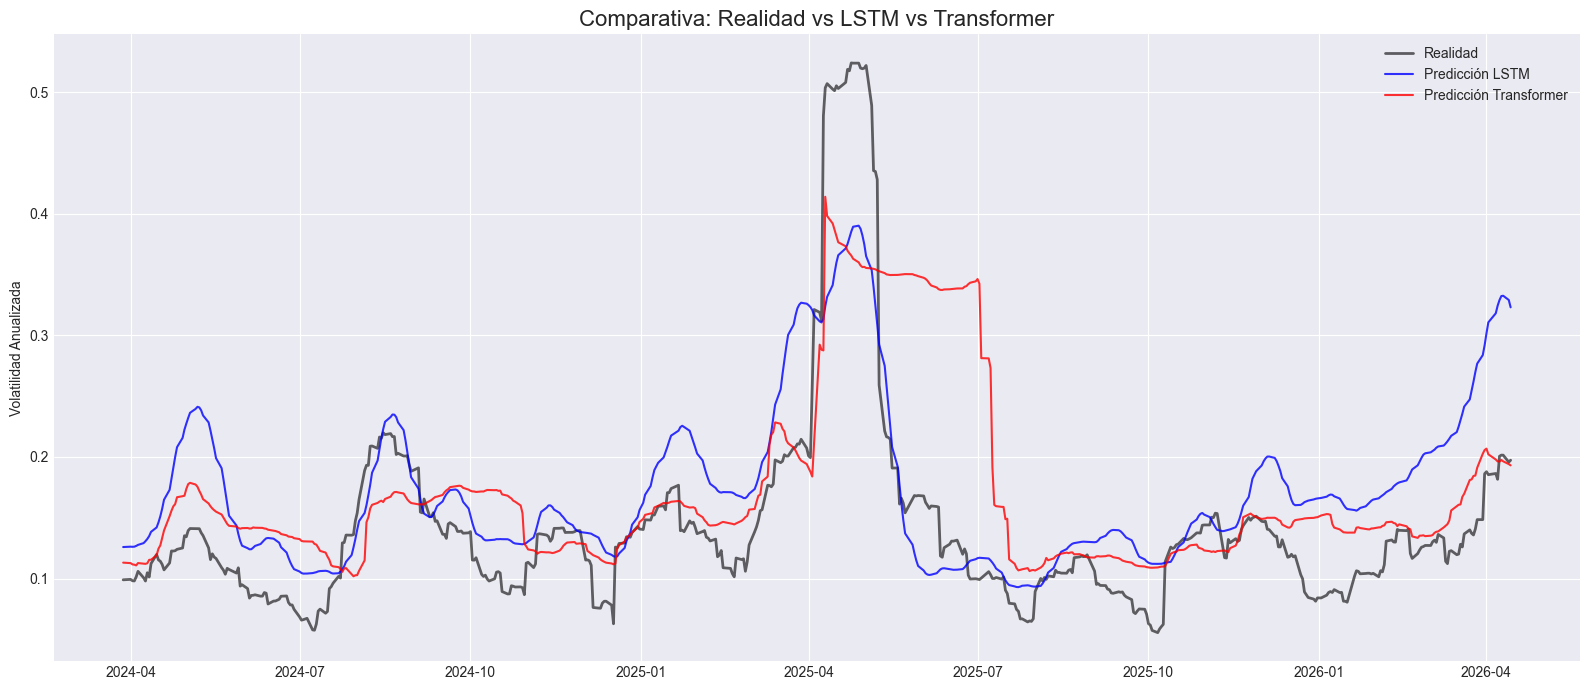

In [9]:
# Generar predicciones en el set de prueba
lstm_predictions_scaled = lstm_model.predict(X_test)
transformer_predictions_scaled = transformer_model.predict(X_test)

# Revertir el escalado a los valores originales de volatilidad
lstm_predictions = target_scaler.inverse_transform(lstm_predictions_scaled)
transformer_predictions = target_scaler.inverse_transform(transformer_predictions_scaled)
y_test_real = target_scaler.inverse_transform(y_test)

# Alinear las fechas (perdimos 'SEQ_LENGTH' días al inicio del test set por la ventana)
fechas_test = test_data.index[SEQ_LENGTH:]

# Creamos un DataFrame con los resultados
df_dl_results = pd.DataFrame(index=fechas_test)
df_dl_results['Realized_Vol (Target)'] = y_test_real
df_dl_results['LSTM_Pred'] = lstm_predictions
df_dl_results['Transformer_Pred'] = transformer_predictions

# Visualización Comparativa
plt.figure(figsize=(16, 7))
plt.plot(df_dl_results.index, df_dl_results['Realized_Vol (Target)'], label='Realidad', color='black', linewidth=2, alpha=0.6)
plt.plot(df_dl_results.index, df_dl_results['LSTM_Pred'], label='Predicción LSTM', color='blue', alpha=0.8)
plt.plot(df_dl_results.index, df_dl_results['Transformer_Pred'], label='Predicción Transformer', color='red', alpha=0.8)

plt.title('Comparativa: Realidad vs LSTM vs Transformer', fontsize=16)
plt.ylabel('Volatilidad Anualizada')
plt.legend()
plt.tight_layout()
plt.show()

# Exportamos los resultados para el Notebook 4 (Comparación Final)
df_dl_results.to_csv('..\data\processed\dl_predictions.csv')